# Profiles

This notebook demonstrates profile and multi-profile analysis using `bathy`.

In [1]:
import bathy

## Load example data

Load the built-in NE Atlantic sample dataset from the GEBCO 2025 grid.

> GEBCO Compilation Group (2025) GEBCO 2025 Grid (doi:10.5285/37c52e96-24ea-67ce-e063-7086abc05f29)

In [2]:
data = bathy.sample_data()
data

<xarray.DataArray 'elevation' (lat: 839, lon: 1645)> Size: 3MB
[1380155 values with dtype=int16]
Coordinates:
  * lat      (lat) float64 7kB 46.05 46.05 46.06 46.06 ... 49.53 49.54 49.54
  * lon      (lon) float64 13kB -12.08 -12.08 -12.07 ... -5.24 -5.235 -5.231
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

In [3]:
# You can also download directly:
# data = bathy.load_gebco_opendap(region="north_atlantic", save_path="gebco.nc")
# data = bathy.load_bathymetry("local_file.nc", lon_range=(-12, -5), lat_range=(46, 50))

## Single profile

Distance: 338998.7 m
Points: 679


(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

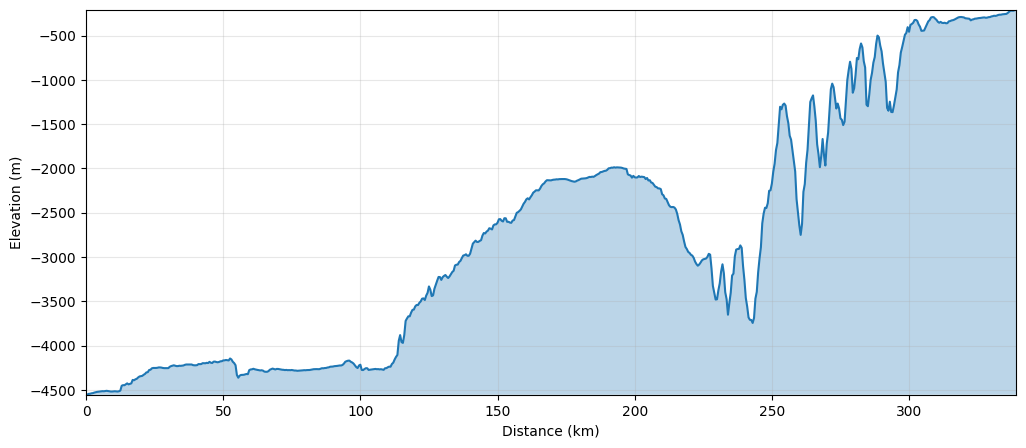

In [4]:
# Create a profile
prof = bathy.extract_profile(
    data, (-11.0, 47.5), (-6.5, 47.5), point_spacing=500.0, name="East-West Profile"
)

print(f"Distance: {prof.distances[-1]:.1f} m")
print(f"Points: {len(prof.distances)}")

bathy.plot_profile(prof)

## Profile with smoothing

(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

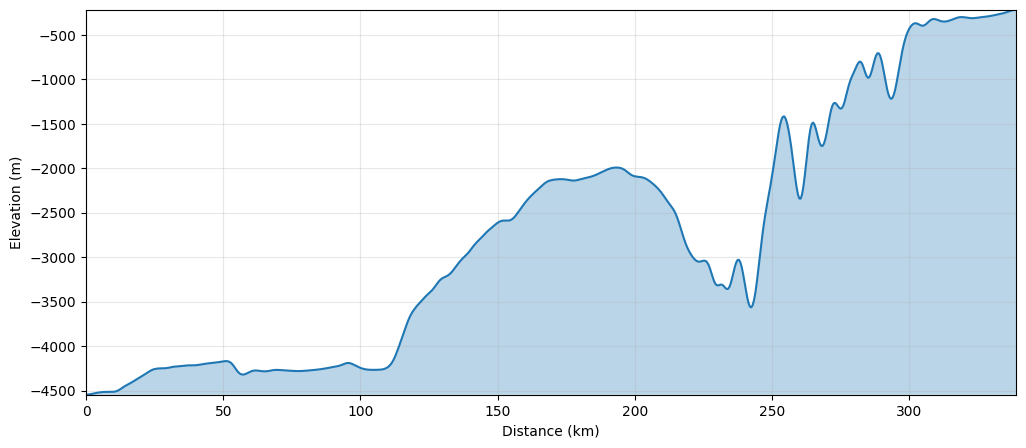

In [5]:
# Compare different smoothing levels
bathy.plot_profile(prof, smooth=3.0)

## Canyon identification

In [6]:
# Identify canyons
canyons = bathy.get_canyons(prof, prominence=500)
canyons

floor_distance,floor_elevation,shoulder_elevation,width_start,width_end,width,depth,cross_sectional_area
f64,f64,f64,f64,f64,f64,f64,f64
233999.084103,-3651.0,-2869.0,218364.224665,238499.06649,20134.841825,782.0,5.3984e6
242999.048876,-3744.0,-2869.0,238499.06649,246036.21171,7537.14522,875.0,3.8544e6
260498.98038,-2750.0,-1268.0,254499.003864,263966.475833,9467.471969,1482.0,6.4808e6
267498.952981,-1986.0,-1176.0,264998.962766,271354.904967,6355.9422,810.0,3.0960e6
284998.884485,-1298.0,-590.0,282498.89427,288030.451566,5531.557296,708.0,1.8041e6


## Visualise canyons

(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

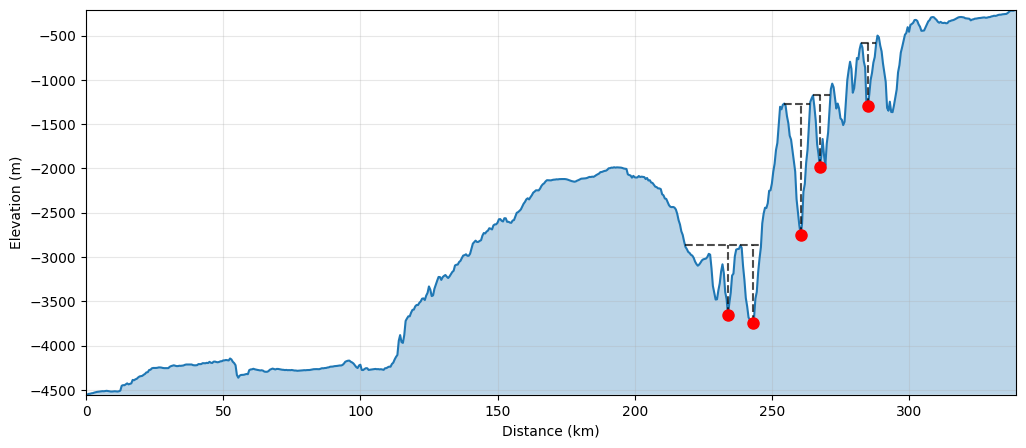

In [7]:
# Plot with canyons highlighted
bathy.plot_canyons(prof, canyons)

## Knickpoint detection

Identify knickpoints (abrupt slope changes) along a profile.

(<Figure size 1200x500 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

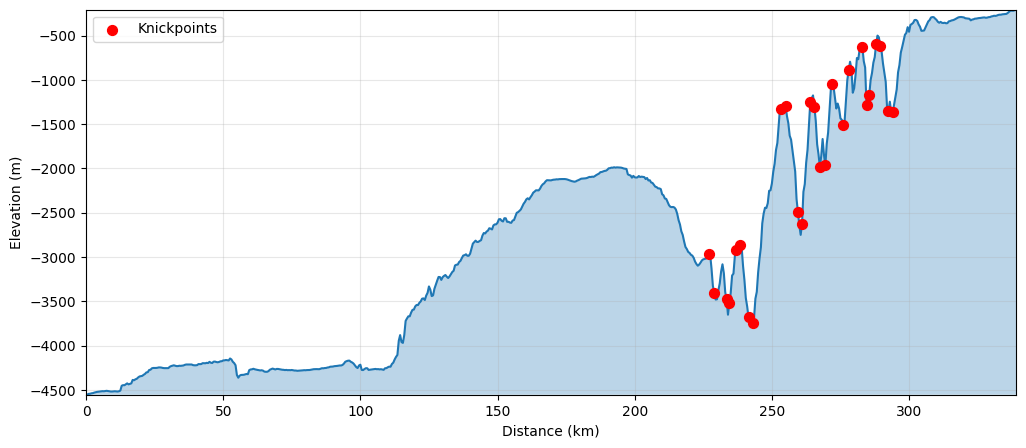

In [8]:
# Detect and plot knickpoints (slope breaks)
kp = bathy.knickpoints(prof, smooth=2)
bathy.plot_knickpoints(prof, kp)

## Multiple profiles

Compare multiple parallel profiles.

In [9]:
# Create multiple profiles
profile_list = []

for lat in [46.5, 47.5, 48.5, 49.0]:
    p = bathy.extract_profile(
        data, (-11.0, lat), (-6.5, lat), num_points=200, name=f"{lat}°N"
    )
    profile_list.append(p)

print(f"Created {len(profile_list)} profiles")

Created 4 profiles


(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

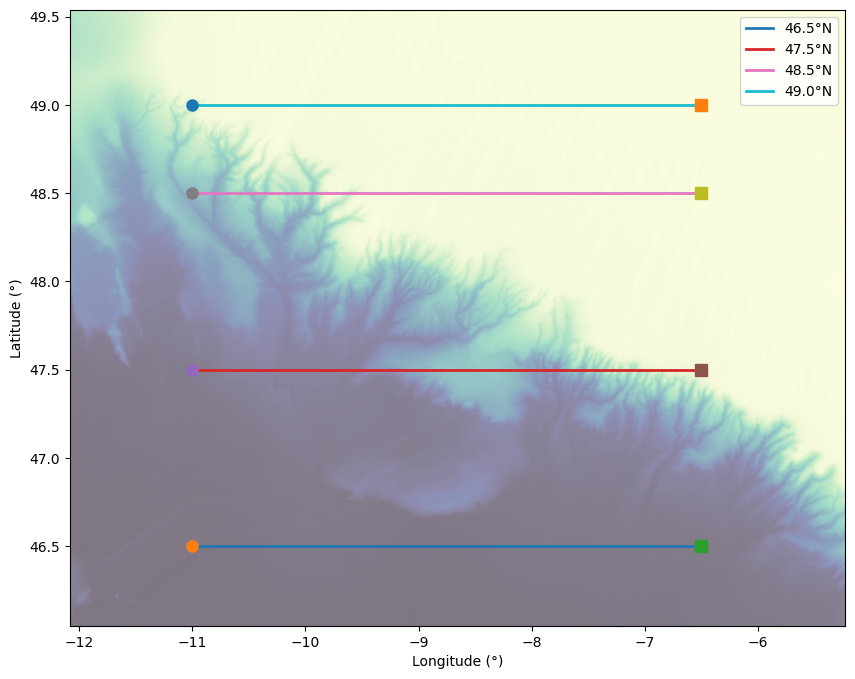

In [10]:
bathy.plot_profiles_map(profile_list, bathymetry_data=data)

### Compare Profiles

(<Figure size 1200x600 with 1 Axes>,
 [<Axes: xlabel='Distance (km)', ylabel='Elevation (m)'>])

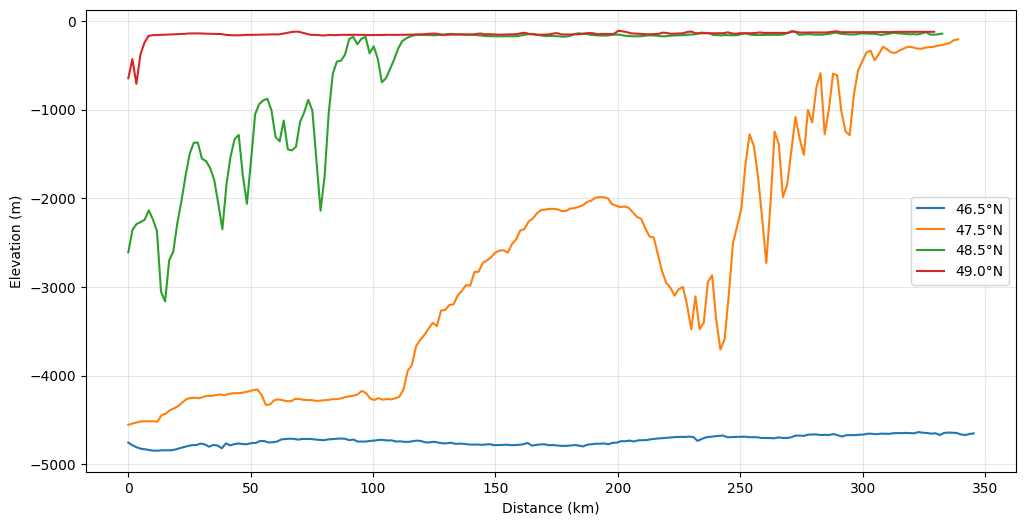

In [11]:
bathy.plot_profiles(profile_list)

### Compare statistics

In [12]:
bathy.compare_stats(profile_list)

statistic,46.5°N,47.5°N,48.5°N,49.0°N
str,f64,f64,f64,f64
"""total_distance_m""",345384.94263,338998.673124,332508.392432,329224.855211
"""min_elevation_m""",-4846.0,-4554.0,-3163.0,-710.0
"""max_elevation_m""",-4636.0,-209.0,-118.0,-112.0
"""mean_elevation_m""",-4729.405,-2748.175,-569.345,-153.4
"""median_elevation_m""",-4730.0,-2830.5,-165.5,-147.0
"""std_elevation_m""",51.95932,1399.6607,731.354453,60.702553
"""elevation_range_m""",210.0,4345.0,3045.0,598.0


## Perpendicular cross-sections

Create cross-sections perpendicular to a profile at regular intervals.

Created 19 cross-sections


(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

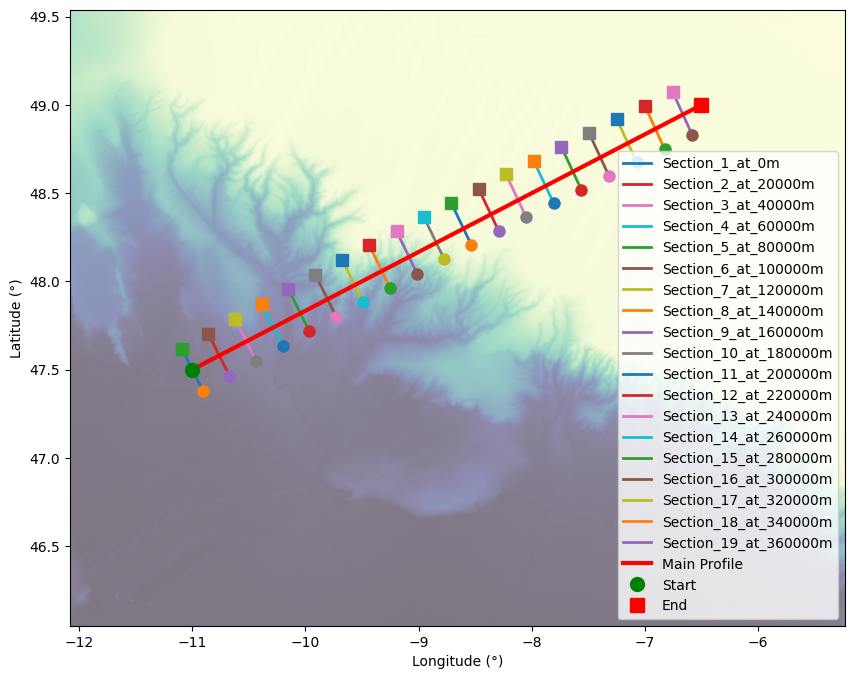

In [13]:
# Create a profile
main_profile = bathy.extract_profile(
    data, (-11.0, 47.5), (-6.5, 49.0), point_spacing=1000.0, name="Main Profile"
)

# Create cross-sections every 20 km with 30 km total width
x_sections = bathy.cross_sections(
    data, main_profile, interval_m=20000, section_width_m=30000, num_points=50
)

print(f"Created {len(x_sections)} cross-sections")

bathy.plot_profiles_map(x_sections, bathymetry_data=data, main_profile=main_profile)

(<Figure size 2100x700 with 6 Axes>,
 array([<Axes: title={'center': 'Section_1_at_0m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Section_2_at_20000m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Section_3_at_40000m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Section_4_at_60000m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Section_5_at_80000m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Section_6_at_100000m (30.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>],
       dtype=object))

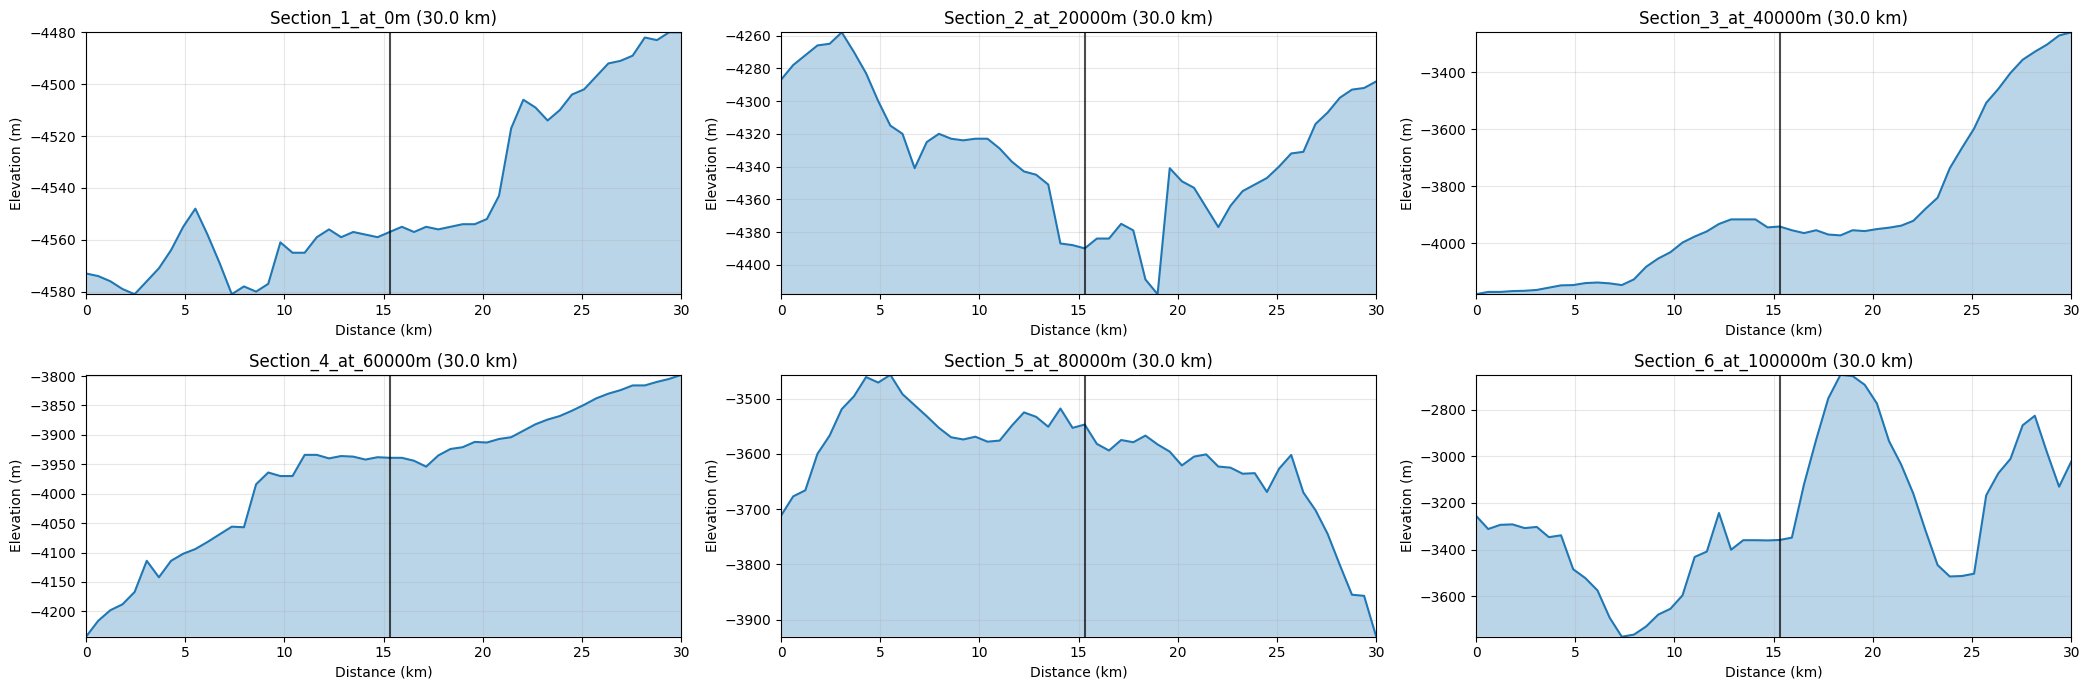

In [14]:
# Plot cross-sections in grid with main profile intersection marked
bathy.plot_profiles_grid(x_sections[:6], cols=3, main_profile=main_profile)

## File import

Load profiles from a vector file of linestrings. This requires your own data files — the example below uses the Global Submarine Canyon Database from Harris & Whiteway (2011) and a local GEBCO NetCDF.

> Harris, P.T. and Whiteway, T. (2011). Global distribution of large submarine canyons: Geomorphic differences between active and passive continental margins. *Marine Geology*, 285(1-4), 69-86.

Loaded 63 canyon profiles


(<Figure size 1400x1750 with 10 Axes>,
 array([<Axes: title={'center': 'Feature_4768 (20.8 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4769 (66.6 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4770 (52.1 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4775 (19.6 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4776 (49.1 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4777 (80.0 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4778 (18.1 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4779 (36.9 km)'}, xlabel='Distance (km)', ylabel='Elevation (m)'>,
        <Axes: title={'center': 'Feature_4780 (23.5 km)'}, xlabel='Distance (km)', ylabel='Elevat

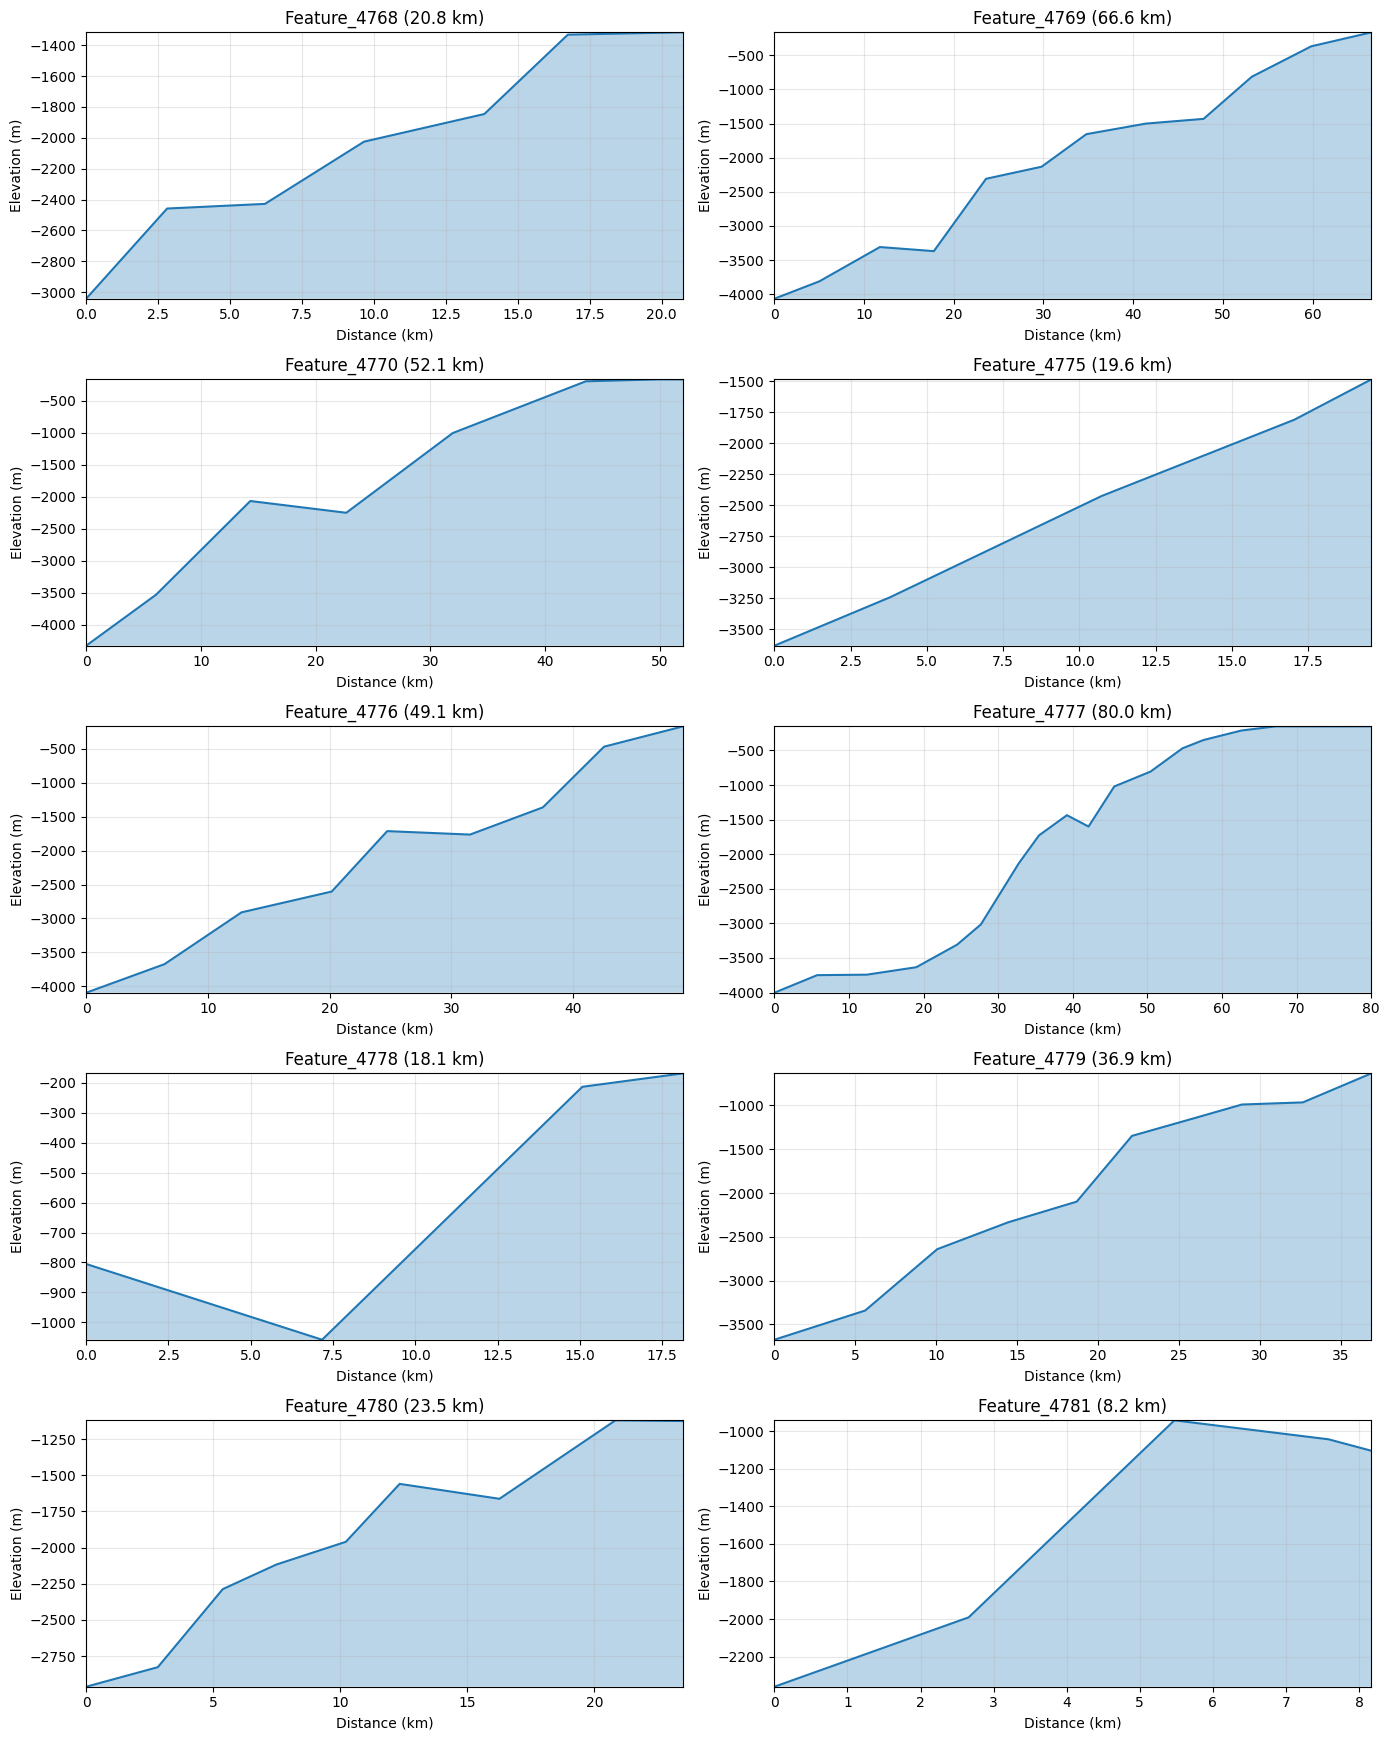

In [15]:
# Load bathymetry data for the Celtic margin
data_clipped = bathy.load_bathymetry(
    "../data/gebco_2025_bathymetry.nc", lon_range=(-12, -4), lat_range=(46, 52)
)

# Load profiles from Global Canyons shapefile
canyon_profiles = bathy.profiles_from_file(
    data_clipped,
    "../data/shp/Global_Canyons.shp",
    id_column="NAME",
)

print(f"Loaded {len(canyon_profiles)} canyon profiles")

# Plot first 10 profiles in a grid
bathy.plot_profiles_grid(canyon_profiles[:10])

### Visualise profiles on a map

(<Figure size 1000x800 with 1 Axes>,
 <Axes: xlabel='Longitude (°)', ylabel='Latitude (°)'>)

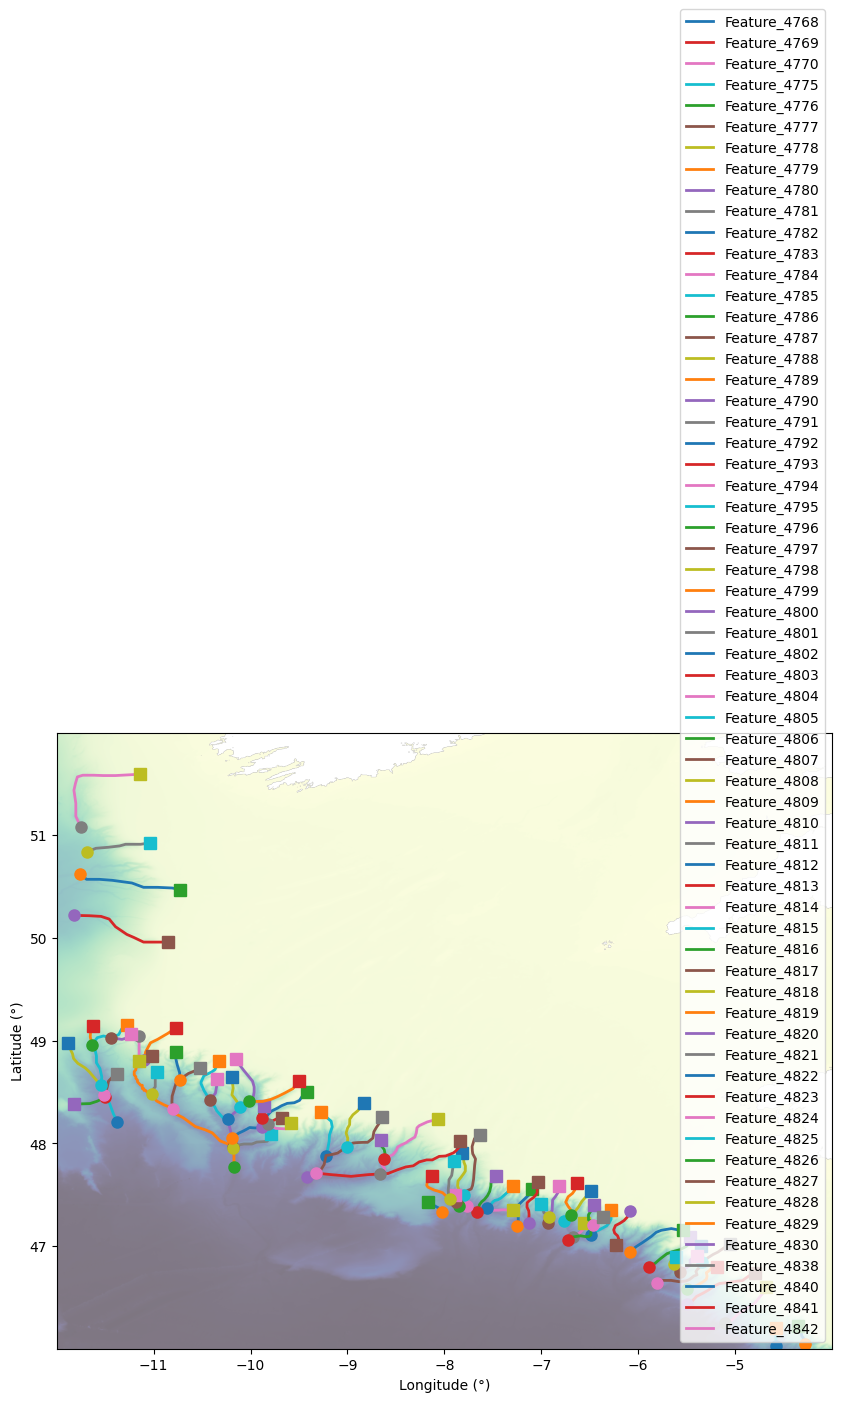

In [16]:
# Plot canyon locations on map
bathy.plot_profiles_map(canyon_profiles, bathymetry_data=data_clipped)